# 🐟 Impact of Image Blur & Enhancement on YOLO-Based Underwater Fish Detection
**Dataset**: URPC2020 (already YOLO format) | **Models**: YOLOv8n, YOLOv11n

Pipeline: Baseline → Blur Simulation → Enhancement → Comparison

## Step 1: Install & Restart

In [ ]:
# Run this cell alone first, then restart kernel, then run from Step 2
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'ultralytics', '-q', '--upgrade'], check=True)
print('Done. Now restart kernel and run from Step 2 onwards.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.1 MB/s eta 0:00:00
Done. Now restart kernel and run from Step 2 onwards.


## Step 2: Imports & Paths

In [ ]:
import os, shutil, random, time, yaml, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
URPC_ROOT   = Path('/kaggle/input/datasets/ishantoraskar/urpc-data/URPC2020')
BASE_DIR    = Path('/kaggle/working')
WORK_DIR    = BASE_DIR / 'yolo_data'       # we'll symlink/copy test images here
RESULTS_DIR = BASE_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)

# ── Read the dataset yaml shipped with URPC ───────────────────────────────────
src_yaml = URPC_ROOT / 'data.yaml'
with open(src_yaml) as f:
    orig_yaml = yaml.safe_load(f)

print('Original data.yaml:')
print(orig_yaml)
CLASS_NAMES = orig_yaml.get('names', [])
NC          = len(CLASS_NAMES)
print(f'\nClasses ({NC}): {CLASS_NAMES}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Original data.yaml:
{'train': '/home/wly/pycharmProjects/underwater-biometrics/data/URPC2020/train/images', 'val': '/home/wly/pycharmProjects/underwater-biometrics/data/URPC2020/valid/images', 'test': '/home/wly/pycharmProjects/underwater-biometrics/data/URPC2020/test/images', 'nc': 4, 'names': ['holothurian', 'echinus', 'scallop', 'starfish'], 'roboflow': {'workspace': 'brad-dwyer', 'project': 'aquarium-combined', 'version': 6, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/brad-dwyer/aquarium-combined/dataset/6'}}

Classes (4): ['holothurian', 'echinus', 'scallop', 'starfish']


## Step 3: Write Fixed dataset.yaml Pointing to URPC Folders

In [ ]:
# YOLO needs absolute paths in yaml
fixed_yaml = {
    'path' : str(URPC_ROOT),
    'train': 'train/images',
    'val'  : 'valid/images',
    'test' : 'test/images',
    'nc'   : NC,
    'names': CLASS_NAMES
}

YAML_PATH = WORK_DIR / 'dataset.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(fixed_yaml, f, default_flow_style=False)

print('dataset.yaml written:')
print(open(YAML_PATH).read())

# Verify image/label counts
for split in ['train', 'valid', 'test']:
    imgs = list((URPC_ROOT / split / 'images').iterdir())
    lbls = list((URPC_ROOT / split / 'labels').iterdir())
    print(f'{split}: {len(imgs)} images, {len(lbls)} labels')

dataset.yaml written:
names:
- holothurian
- echinus
- scallop
- starfish
nc: 4
path: /kaggle/input/datasets/ishantoraskar/urpc-data/URPC2020
test: test/images
train: train/images
val: valid/images

train: 5543 images, 5543 labels
valid: 1200 images, 1200 labels
test: 800 images, 800 labels


## Step 4: Baseline Training — YOLOv8n & YOLOv11n

In [ ]:
EPOCHS   = 50
IMG_SIZE = 640
BATCH    = 32
PATIENCE = 10

trained_models = {}

for model_name, weights in [
    ('YOLOv8n', 'yolov8n.pt'),
    ('YOLOv11n', 'yolo11n.pt')
]:
    print(f'\n{"+"*60}\nTraining {model_name}\n{"+"*60}')

    model = YOLO(weights)

    model.train(
        data     = str(YAML_PATH),
        epochs   = EPOCHS,
        imgsz    = IMG_SIZE,
        batch    = BATCH,
        patience = PATIENCE,

        # ✅ SINGLE GPU (REALITY)
        device   = 0,

        # ⚡ SPEED OPTIMIZATION
        workers  = 4,
        cache    = True,

        project  = str(RESULTS_DIR / 'train'),
        name     = model_name,
        exist_ok = True,
        verbose  = True
    )

    best_pt = RESULTS_DIR / 'train' / model_name / 'weights' / 'best.pt'
    trained_models[model_name] = str(best_pt)

    print(f'Saved: {best_pt}')


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Training YOLOv8n
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosa

## Step 5: Baseline Evaluation on Clear Test Images

In [ ]:
def get_metrics(weights, yaml_path, test_imgs_dir, split='test'):
    model   = YOLO(weights)
    metrics = model.val(data=str(yaml_path), split=split,
                        imgsz=IMG_SIZE, batch=BATCH, verbose=False)
    # FPS on first 50 test images
    sample = list(Path(test_imgs_dir).iterdir())[:50]
    t0  = time.time()
    model.predict(sample, imgsz=IMG_SIZE, verbose=False)
    fps = len(sample) / (time.time() - t0)
    p, r = metrics.box.mp, metrics.box.mr
    return {
        'mAP50'    : round(metrics.box.map50, 4),
        'Precision': round(p, 4),
        'Recall'   : round(r, 4),
        'F1'       : round(2*p*r/(p+r+1e-9), 4),
        'FPS'      : round(fps, 1)
    }

TEST_IMG_DIR = URPC_ROOT / 'test' / 'images'

baseline = {}
for mname, wts in trained_models.items():
    print(f'Evaluating {mname}...')
    baseline[mname] = get_metrics(wts, YAML_PATH, TEST_IMG_DIR)
    print(baseline[mname])

df_baseline = pd.DataFrame(baseline).T
print('\n── Baseline ──')
print(df_baseline)

BEST_MODEL = df_baseline['mAP50'].idxmax()
BEST_WTS   = trained_models[BEST_MODEL]
CLEAR_MAP  = baseline[BEST_MODEL]['mAP50']
print(f'\nBest model: {BEST_MODEL}  mAP50={CLEAR_MAP}')

Evaluating YOLOv8n...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11.7±12.5 MB/s, size: 222.8 KB)
val: Scanning /kaggle/input/datasets/ishantoraskar/urpc-data/URPC2020/test/labels... 800 images, 25 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 800/800 82.6it/s 9.7s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ishantoraskar/urpc-data/URPC2020/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 2.1it/s 11.7s0.3s
                   all        800       6581       0.79      0.673      0.749      0.424
Speed: 1.4ms preprocess, 2.3ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
{'mAP50': np.float64(0.7487), 'Precision': np.float64(0.7896), 'Recall': np.float64(0

## Step 6: Blur Simulation

In [ ]:
# ── Blur functions ────────────────────────────────────────────────────────────
def gaussian_blur(img, sigma):
    k = int(6*sigma+1) | 1
    return cv2.GaussianBlur(img, (k,k), sigma)

def motion_blur(img, k):
    kernel = np.zeros((k,k))
    kernel[k//2, :] = 1.0 / k
    return cv2.filter2D(img, -1, kernel)

BLUR_CONFIGS = {
    'gaussian_s1' : lambda i: gaussian_blur(i, 1),
    'gaussian_s3' : lambda i: gaussian_blur(i, 3),
    'gaussian_s5' : lambda i: gaussian_blur(i, 5),
    'motion_k5'   : lambda i: motion_blur(i, 5),
    'motion_k10'  : lambda i: motion_blur(i, 10),
    'motion_k15'  : lambda i: motion_blur(i, 15),
}

def make_transformed_testset(tag, transform_fn, src_dir=TEST_IMG_DIR):
    """Apply transform to all test images, save to working dir."""
    out_dir = WORK_DIR / f'test_{tag}' / 'images'
    out_dir.mkdir(parents=True, exist_ok=True)
    for p in Path(src_dir).iterdir():
        img = cv2.imread(str(p))
        if img is None: continue
        cv2.imwrite(str(out_dir / p.name), transform_fn(img))
    return out_dir

def make_temp_yaml(img_dir):
    """Write a temp yaml pointing test split to a custom image folder.
       Labels are always from the original test/labels."""
    # YOLO resolves labels from images path by replacing /images/ -> /labels/
    # So we symlink the labels folder next to our images folder
    lbl_link = img_dir.parent / 'labels'
    if not lbl_link.exists():
        lbl_link.symlink_to(URPC_ROOT / 'test' / 'labels')
    tmp = {
        'path' : str(img_dir.parent.parent),
        'train': str(URPC_ROOT / 'train' / 'images'),
        'val'  : str(URPC_ROOT / 'valid' / 'images'),
        'test' : str(img_dir),
        'nc'   : NC,
        'names': CLASS_NAMES
    }
    yp = img_dir.parent / 'tmp.yaml'
    with open(yp, 'w') as f:
        yaml.dump(tmp, f)
    return yp

def eval_on_dir(weights, img_dir):
    yp    = make_temp_yaml(img_dir)
    model = YOLO(weights)
    met   = model.val(data=str(yp), split='test',
                      imgsz=IMG_SIZE, batch=BATCH, verbose=False)
    imgs  = list(img_dir.iterdir())[:50]
    t0    = time.time()
    model.predict(imgs, imgsz=IMG_SIZE, verbose=False)
    fps   = len(imgs) / (time.time() - t0)
    p, r  = met.box.mp, met.box.mr
    return {
        'mAP50'    : round(met.box.map50, 4),
        'Precision': round(p, 4),
        'Recall'   : round(r, 4),
        'F1'       : round(2*p*r/(p+r+1e-9), 4),
        'FPS'      : round(fps, 1)
    }

# ── Run blur evaluations ──────────────────────────────────────────────────────
blur_results = {'clear': baseline[BEST_MODEL]}
blur_dirs    = {}

for bname, bfn in BLUR_CONFIGS.items():
    print(f'  Creating & evaluating {bname}...')
    bdir = make_transformed_testset(bname, bfn)
    blur_dirs[bname]    = bdir
    blur_results[bname] = eval_on_dir(BEST_WTS, bdir)
    print(f'    mAP50 = {blur_results[bname]["mAP50"]}')

df_blur = pd.DataFrame(blur_results).T
print('\n── Blur Results ──')
print(df_blur)

  Creating & evaluating gaussian_s1...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2134.5±1449.6 MB/s, size: 628.3 KB)
val: Scanning /kaggle/working/yolo_data/test_gaussian_s1/labels.cache... 800 images, 25 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 800/800 335.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 1.9it/s 13.0s0.4s
                   all        800       6581      0.792      0.672      0.763       0.43
Speed: 1.9ms preprocess, 2.3ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val14
    mAP50 = 0.7633
  Creating & evaluating gaussian_s3...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0

## Step 7: Image Enhancement

In [ ]:
# ── Enhancement functions ─────────────────────────────────────────────────────
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l,a,b = cv2.split(lab)
    cl = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(l)
    return cv2.cvtColor(cv2.merge((cl,a,b)), cv2.COLOR_LAB2BGR)

def apply_retinex(img, sigmas=(15)):
    img_f = img.astype(np.float32) + 1.0
    msr   = np.zeros_like(img_f)
    for s in sigmas:
        msr += np.log10(img_f) - np.log10(cv2.GaussianBlur(img_f,(0,0),s) + 1.0)
    msr /= len(sigmas)
    out = np.zeros_like(img_f)
    for c in range(3):
        ch = msr[:,:,c]
        out[:,:,c] = (ch-ch.min())/(ch.max()-ch.min()+1e-9)*255
    return np.clip(out,0,255).astype(np.uint8)

ENHANCE_CONFIGS = {'clahe': apply_clahe}

# ── Evaluate enhancement on: clear images + worst blurred images ──────────────
WORST_BLURS  = sorted(blur_dirs, key=lambda k: blur_results[k]['mAP50'])[:2]
print(f'Worst blurs selected for enhancement: {WORST_BLURS}')

enh_results = {}

# Enhancement on clear images
for ename, efn in ENHANCE_CONFIGS.items():
    tag  = f'clear+{ename}'
    print(f'  {tag}...')
    edir = make_transformed_testset(tag, efn, src_dir=TEST_IMG_DIR)
    enh_results[tag] = eval_on_dir(BEST_WTS, edir)
    print(f'    mAP50 = {enh_results[tag]["mAP50"]}')

# Enhancement on blurred images
for bname in WORST_BLURS:
    bdir = blur_dirs[bname]
    for ename, efn in ENHANCE_CONFIGS.items():
        tag  = f'{bname}+{ename}'
        print(f'  {tag}...')
        edir = make_transformed_testset(tag, efn, src_dir=bdir)
        enh_results[tag] = eval_on_dir(BEST_WTS, edir)
        print(f'    mAP50 = {enh_results[tag]["mAP50"]}')

df_enh = pd.DataFrame(enh_results).T
print('\n── Enhancement Results ──')
print(df_enh)

Worst blurs selected for enhancement: ['gaussian_s5', 'motion_k15']
  clear+clahe...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3275.5±133.7 MB/s, size: 1336.8 KB)
val: Scanning /kaggle/working/yolo_data/test_clear+clahe/labels... 800 images, 25 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 800/800 882.2it/s 0.9s<0.0s
val: New cache created: /kaggle/working/yolo_data/test_clear+clahe/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 1.7it/s 14.7s0.4s
                   all        800       6581      0.762      0.572      0.665      0.361
Speed: 1.6ms preprocess, 2.3ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /kaggle/working/runs/detect/val20
    mAP50 = 0.6653
  gaussian_s5+clahe...
Ultralytics 8.4.33 🚀 Python-3.12.12

## Step 8: Full Comparison Table

In [ ]:
def pct(val, ref): return round((val-ref)/ref*100, 2)

all_res = {**blur_results, **enh_results}
df_all  = pd.DataFrame(all_res).T.reset_index().rename(columns={'index':'Condition'})
df_all['vs_clear(%)'] = df_all['mAP50'].apply(lambda x: pct(x, CLEAR_MAP))

def recovery(row):
    cond = row['Condition']
    if '+' not in cond: return np.nan
    blur_part = cond.split('+')[0]
    if blur_part == 'clear' or blur_part not in blur_results: return np.nan
    bm = blur_results[blur_part]['mAP50']
    return round((row['mAP50']-bm)/(CLEAR_MAP-bm+1e-9)*100, 2)

df_all['Recovery(%)'] = df_all.apply(recovery, axis=1)
df_all.to_csv(RESULTS_DIR/'comparison.csv', index=False)

print('═'*80)
print(df_all.to_string(index=False))
print('═'*80)

════════════════════════════════════════════════════════════════════════════════
        Condition  mAP50  Precision  Recall     F1  FPS  vs_clear(%)  Recovery(%)
            clear 0.7577     0.7839  0.6742 0.7249  8.7         0.00          NaN
      gaussian_s1 0.7633     0.7923  0.6715 0.7269  8.3         0.74          NaN
      gaussian_s3 0.7308     0.7823  0.6400 0.7041  8.4        -3.55          NaN
      gaussian_s5 0.6726     0.7536  0.5967 0.6660  8.5       -11.23          NaN
        motion_k5 0.7614     0.7892  0.6723 0.7261  8.3         0.49          NaN
       motion_k10 0.7424     0.7577  0.6622 0.7068  8.2        -2.02          NaN
       motion_k15 0.7174     0.7676  0.6356 0.6954  8.4        -5.32          NaN
      clear+clahe 0.6653     0.7620  0.5722 0.6536  7.9       -12.19          NaN
gaussian_s5+clahe 0.5488     0.6927  0.4831 0.5692  7.8       -27.57      -145.48
 motion_k15+clahe 0.6140     0.7084  0.5490 0.6186  7.8       -18.97      -256.58
═════════════════

## Step 9: Visualizations

/tmp/ipykernel_55/2890086975.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(blur_keys, rotation=30, ha='right')


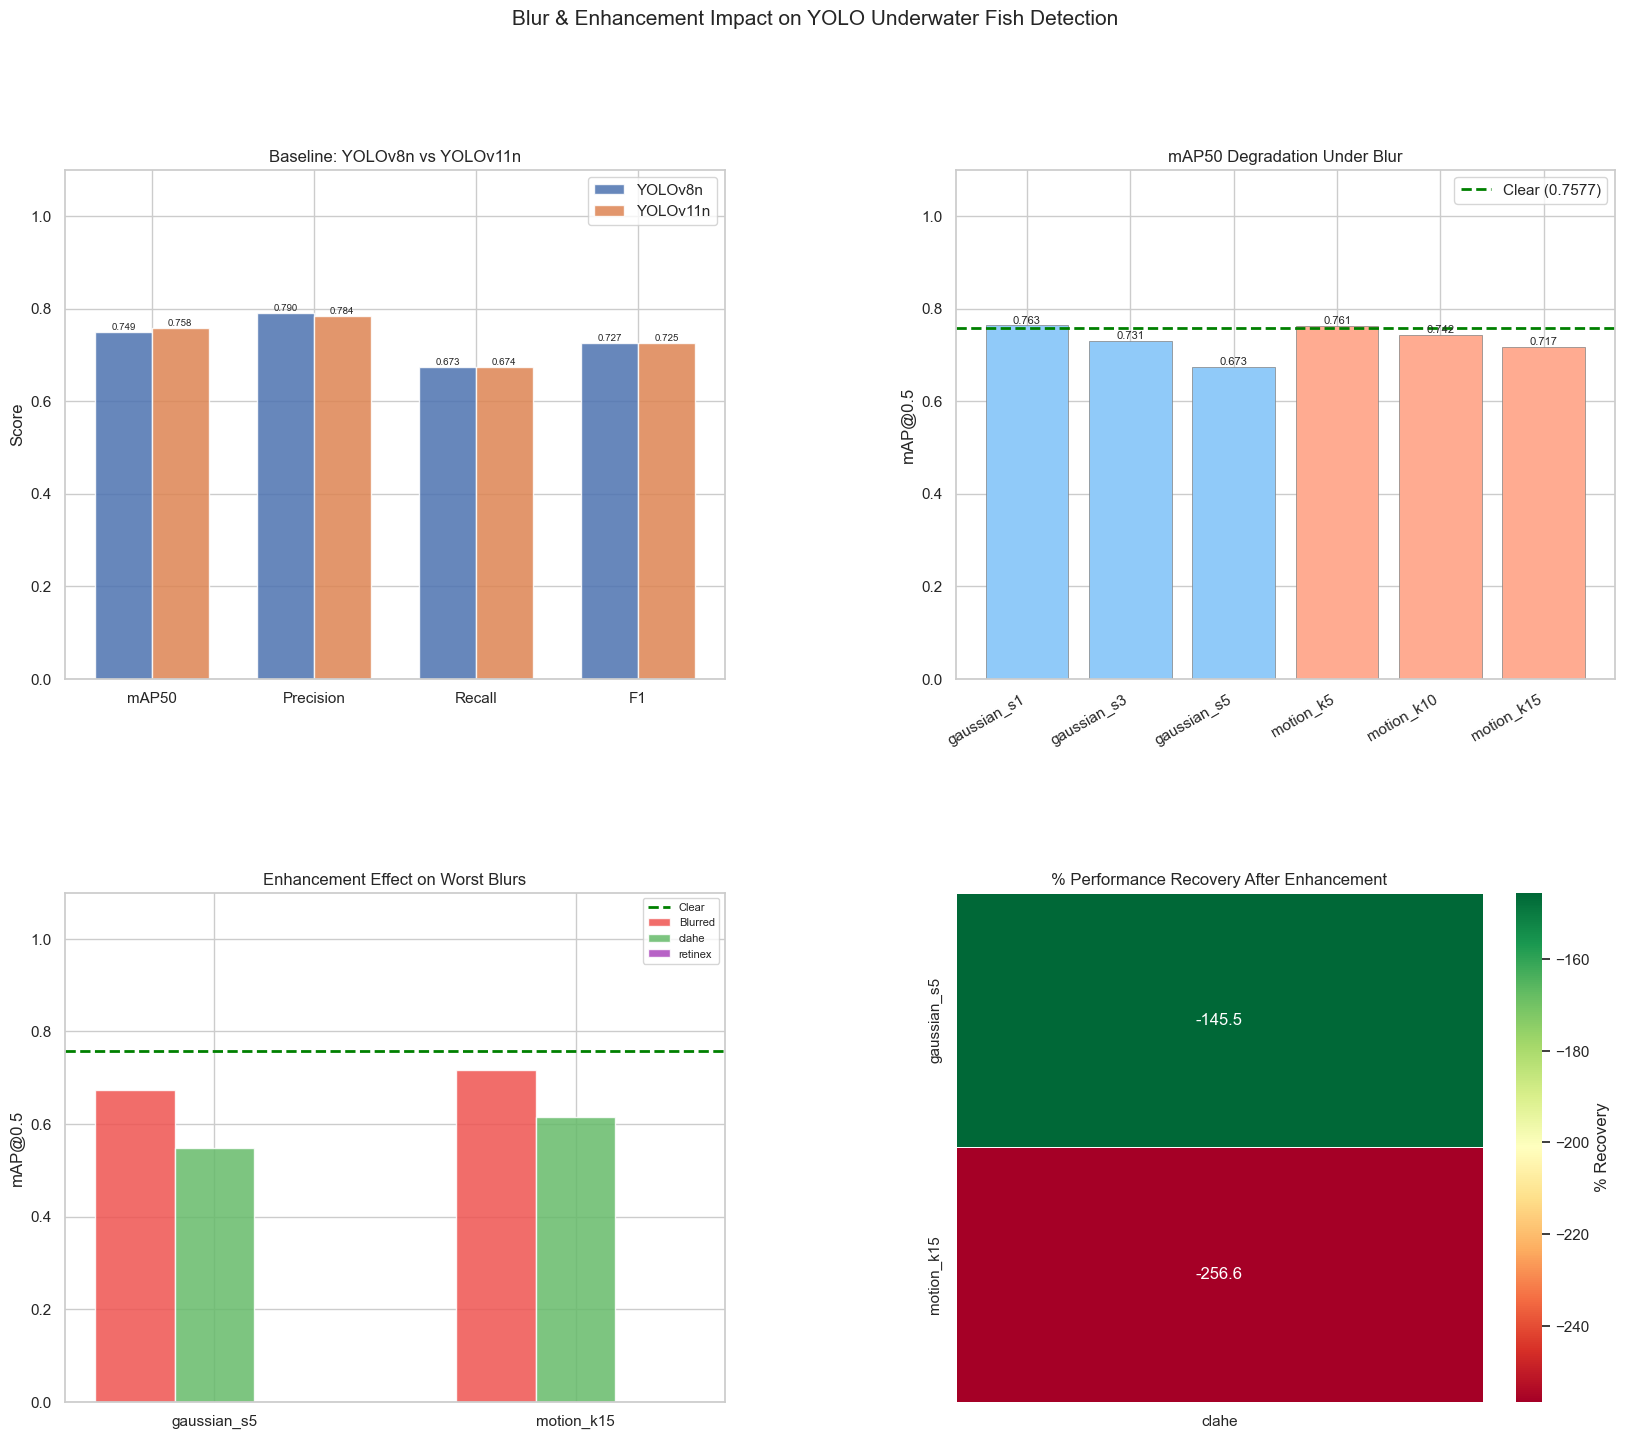

Saved: analysis.png


In [ ]:
sns.set_theme(style='whitegrid')
fig = plt.figure(figsize=(20,16))
fig.suptitle('Blur & Enhancement Impact on YOLO Underwater Fish Detection',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

# ── 1. Baseline model comparison ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0,0])
metrics_k = ['mAP50','Precision','Recall','F1']
x = np.arange(len(metrics_k)); w = 0.35
for i,(mn,mr) in enumerate(baseline.items()):
    bars = ax1.bar(x+i*w, [mr[k] for k in metrics_k], w,
                   label=mn, alpha=0.85)
    for b in bars:
        ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                 f'{b.get_height():.3f}', ha='center', fontsize=7)
ax1.set_xticks(x+w/2); ax1.set_xticklabels(metrics_k)
ax1.set_ylim(0,1.1); ax1.set_title('Baseline: YOLOv8n vs YOLOv11n')
ax1.legend(); ax1.set_ylabel('Score')

# ── 2. mAP50 drop under blur ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0,1])
blur_keys = [k for k in blur_results if k != 'clear']
blur_maps = [blur_results[k]['mAP50'] for k in blur_keys]
colors    = ['#90CAF9']*3 + ['#FFAB91']*3
bars = ax2.bar(blur_keys, blur_maps, color=colors, edgecolor='grey', lw=0.5)
ax2.axhline(CLEAR_MAP, color='green', ls='--', lw=2, label=f'Clear ({CLEAR_MAP})')
for b in bars:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
             f'{b.get_height():.3f}', ha='center', fontsize=8)
ax2.set_xticklabels(blur_keys, rotation=30, ha='right')
ax2.set_ylim(0,1.1); ax2.set_title('mAP50 Degradation Under Blur')
ax2.set_ylabel('mAP@0.5'); ax2.legend()

# ── 3. Enhancement recovery bars ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1,0])
groups  = WORST_BLURS
x3 = np.arange(len(groups)); w3 = 0.22
slots   = ['Blurred','clahe','retinex']
ecolors = ['#EF5350','#66BB6A','#AB47BC']
for i,(lbl,col) in enumerate(zip(slots, ecolors)):
    if lbl == 'Blurred':
        vals = [blur_results[g]['mAP50'] for g in groups]
    else:
        vals = [enh_results.get(f'{g}+{lbl}',{}).get('mAP50',0) for g in groups]
    ax3.bar(x3+(i-1)*w3, vals, w3, label=lbl, color=col, alpha=0.85)
ax3.axhline(CLEAR_MAP, color='green', ls='--', lw=2, label='Clear')
ax3.set_xticks(x3); ax3.set_xticklabels(groups)
ax3.set_ylim(0,1.1); ax3.set_title('Enhancement Effect on Worst Blurs')
ax3.set_ylabel('mAP@0.5'); ax3.legend(fontsize=8)

# ── 4. Recovery heatmap ────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1,1])
heat = pd.DataFrame(index=WORST_BLURS, columns=list(ENHANCE_CONFIGS.keys()), dtype=float)
for b in WORST_BLURS:
    for e in ENHANCE_CONFIGS:
        row = df_all[df_all['Condition']==f'{b}+{e}']
        if not row.empty:
            heat.loc[b,e] = row['Recovery(%)'].values[0]
sns.heatmap(heat.astype(float), annot=True, fmt='.1f', cmap='RdYlGn',
            ax=ax4, linewidths=0.5, cbar_kws={'label':'% Recovery'})
ax4.set_title('% Performance Recovery After Enhancement')

plt.savefig(RESULTS_DIR/'analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: analysis.png')

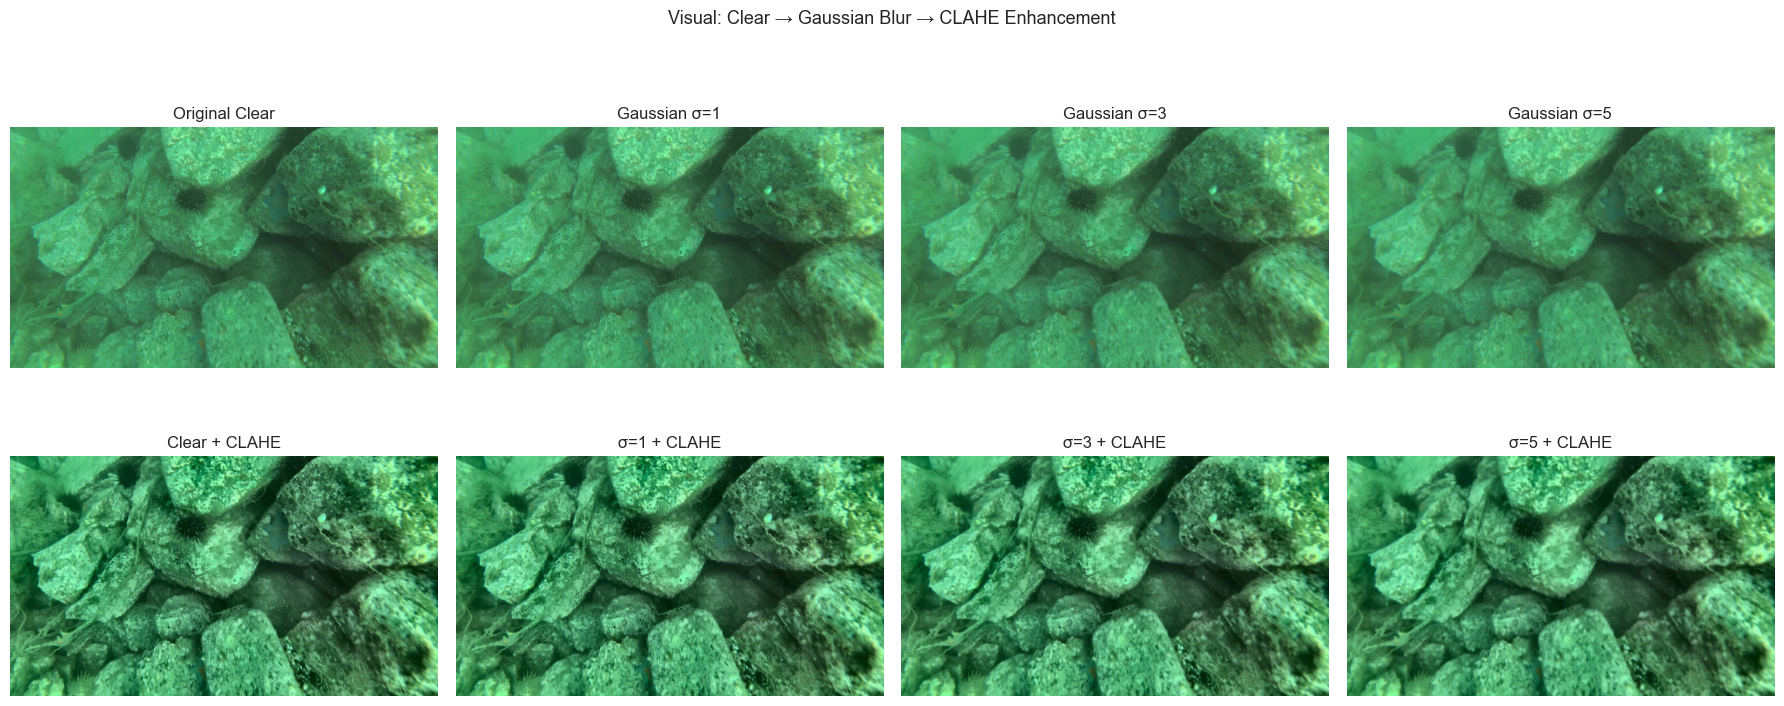

In [ ]:
# ── Visual sample: Clear → Blur → Enhanced ────────────────────────────────────
sample = random.choice(list(TEST_IMG_DIR.iterdir()))
orig   = cv2.imread(str(sample))

fig, axes = plt.subplots(2, 4, figsize=(18,8))
fig.suptitle('Visual: Clear → Gaussian Blur → CLAHE Enhancement', fontsize=13, fontweight='bold')

sigmas = [1, 3, 5]
axes[0][0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
axes[0][0].set_title('Original Clear', fontweight='bold')
for i, s in enumerate(sigmas):
    blurred = gaussian_blur(orig, s)
    axes[0][i+1].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
    axes[0][i+1].set_title(f'Gaussian σ={s}')

axes[1][0].imshow(cv2.cvtColor(apply_clahe(orig), cv2.COLOR_BGR2RGB))
axes[1][0].set_title('Clear + CLAHE', fontweight='bold')
for i, s in enumerate(sigmas):
    enhanced = apply_clahe(gaussian_blur(orig, s))
    axes[1][i+1].imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
    axes[1][i+1].set_title(f'σ={s} + CLAHE')

for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS_DIR/'visual_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 10: Final Summary

In [ ]:
print('='*70)
print('FINAL SUMMARY')
print('='*70)

print(f'\nBest Baseline Model : {BEST_MODEL}')
print(f'Clear mAP50         : {CLEAR_MAP}')
print(pd.DataFrame([baseline[BEST_MODEL]]).to_string(index=False))

worst = min((k for k in blur_results if k!='clear'),
            key=lambda k: blur_results[k]['mAP50'])
print(f'\nWorst Blur: {worst}  →  mAP50={blur_results[worst]["mAP50"]}  '
      f'(drop={pct(blur_results[worst]["mAP50"], CLEAR_MAP)}%)')

if enh_results:
    best_enh = max(enh_results, key=lambda k: enh_results[k]['mAP50'])
    print(f'Best Enhancement    : {best_enh}  →  mAP50={enh_results[best_enh]["mAP50"]}')

print('\nSaved files:')
for f in sorted(RESULTS_DIR.rglob('*.csv')) + sorted(RESULTS_DIR.rglob('*.png')):
    print(f'  {f}')

print('\nPIPELINE COMPLETE')

FINAL SUMMARY

Best Baseline Model : YOLOv11n
Clear mAP50         : 0.7577
 mAP50  Precision  Recall     F1  FPS
0.7577     0.7839  0.6742 0.7249  8.7

Worst Blur: gaussian_s5  →  mAP50=0.6726  (drop=-11.23%)
Best Enhancement    : clear+clahe  →  mAP50=0.6653

Saved files:
  /kaggle/working/results/comparison.csv
  /kaggle/working/results/train/YOLOv11n/results.csv
  /kaggle/working/results/train/YOLOv8n/results.csv
  /kaggle/working/results/analysis.png
  /kaggle/working/results/train/YOLOv11n/BoxF1_curve.png
  /kaggle/working/results/train/YOLOv11n/BoxPR_curve.png
  /kaggle/working/results/train/YOLOv11n/BoxP_curve.png
  /kaggle/working/results/train/YOLOv11n/BoxR_curve.png
  /kaggle/working/results/train/YOLOv11n/confusion_matrix.png
  /kaggle/working/results/train/YOLOv11n/confusion_matrix_normalized.png
  /kaggle/working/results/train/YOLOv11n/results.png
  /kaggle/working/results/train/YOLOv8n/BoxF1_curve.png
  /kaggle/working/results/train/YOLOv8n/BoxPR_curve.png
  /kaggle/worki